# Analisis Sentimen dan Pemodelan Topik Ulasan Wisatawan tentang Lawang Sewu

### 1. Judul & Tujuan Penelitian

**Judul:** Analisis Sentimen dan Pemodelan Topik Ulasan Wisatawan tentang Lawang Sewu

**Tujuan:**
1.  **Klasifikasi Sentimen:** Mengklasifikasikan ulasan dari Google Reviews ke dalam sentimen **positif, negatif, atau netral** secara terawasi (*supervised*).
2.  **Pemodelan Topik:** Mengungkap topik-topik utama yang dibicarakan dalam ulasan menggunakan *Latent Dirichlet Allocation* (LDA).
3.  **Analisis Terpadu:** Mengaitkan hasil sentimen dengan topik yang ditemukan untuk memberikan rekomendasi perbaikan layanan yang actionable bagi pengelola Lawang Sewu.

### 2. Deskripsi Dataset & Sumber Data

* **Sumber Data:** Google Maps/Reviews. Platform ini dipilih karena memiliki volume ulasan yang signifikan dibandingkan platform lain yang datanya "terlalu sedikit dan tidak ada value".
* **Ukuran Dataset:** **3.500 ulasan** yang telah dilabeli secara manual dengan sentimen (positif, negatif, netral).
* **Struktur Data (Kolom Kunci):**
    * `text`: Isi ulasan asli dari pengguna.
    * `label`: Sentimen yang telah ditentukan (POSITIF, NEGATIF, NETRAL).
    * *(Opsional)*: `date`, `rating`, `user_id` (jika tersedia dan dianonimkan).
* **Catatan Etika & Legal:**
    * Proses *scraping* data dilakukan secara etis dan menghormati *Terms of Service* (TOS) Google.
    * Data pengguna seperti nama atau ID akan dianonimkan untuk menjaga privasi.

### 3. Ringkasan Alur Metodologi

Penelitian ini akan mengikuti alur kerja standar dalam proyek *Natural Language Processing* (NLP):

1.  **Setup & Audit Data**: Mempersiapkan lingkungan kerja, memuat data, dan melakukan analisis data eksplorasi awal untuk memahami karakteristik dataset.
2.  **Preprocessing Teks**: Membersihkan dan menormalisasi data teks (termasuk *cleaning*, *case folding*, *tokenisasi*, *stopword removal*, dan *stemming*).
3.  **Deduplikasi**: Menghapus ulasan duplikat (baik yang identik maupun yang sangat mirip) untuk memastikan kualitas model.
4.  **Pembagian Data**: Membagi dataset secara *stratified* menjadi data latih, validasi, dan uji untuk evaluasi model yang adil.
5.  **Analisis Sentimen (Supervised):**
    * **Ekstraksi Fitur**: Mengubah teks menjadi representasi numerik menggunakan TF-IDF.
    * **Seleksi Model**: Melakukan *screening* cepat dengan LazyPredict, dilanjutkan dengan validasi silang pada model kandidat (LinearSVC, LogisticRegression, ComplementNB).
    * **Tuning & Evaluasi**: Melakukan *hyperparameter tuning* pada model terbaik dan mengevaluasi performanya secara terstruktur pada data uji.
6.  **Pemodelan Topik (Unsupervised):**
    * **Persiapan Korpus**: Membangun kamus dan korpus dari teks bersih.
    * **Pencarian Jumlah Topik**: Menggunakan metrik *Coherence Score* (c_v) untuk menemukan jumlah topik (k) yang optimal.
    * **Interpretasi & Visualisasi**: Melatih model LDA final dan membuat visualisasi interaktif dengan pyLDAvis.
7.  **Integrasi & Laporan**: Menggabungkan hasil sentimen dan topik untuk menarik kesimpulan dan memberikan rekomendasi.

### 4. Setup Lingkungan & Reproducibility

Langkah pertama adalah mengimpor pustaka yang dibutuhkan, mengatur *seed* untuk reproduktifitas, dan membuat folder untuk menyimpan artefak hasil analisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import json
import os
import sys
import joblib
from tqdm.notebook import tqdm
tqdm.pandas()

# Library untuk NLP dan Machine Learning
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestCentroid

from lightgbm import LGBMClassifier

import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

!pip install Sastrawi thefuzz
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from thefuzz import fuzz # untuk near-duplicate detection

# Pengaturan umum
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

# Buat folder artefak jika belum ada
if not os.path.exists('artefak'):
    os.makedirs('artefak')
    
print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("gensim version:", gensim.__version__)
print("pyLDAvis version:", pyLDAvis.__version__)
print("Setup selesai. Folder 'artefak/' siap digunakan.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.8 MB/s eta 0:00:00
Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
pandas version: 2.2.3
scikit-learn version: 1.2.2
gensim version: 4.3.3
pyLDAvis version: 3.4.0
Setup selesai. Folder 'artefak/' siap digunakan.


### 5. Audit Data Awal

Kita akan memuat dataset dan melakukan pemeriksaan awal untuk memahami struktur, tipe data, dan distribusi label sentimen.

Dataset berhasil dimuat: 3506 baris dan 3 kolom.

Contoh 5 baris data awal:


,No,Text,Label
0,1,Tempat wisata yang bersejarah,POSITIF
1,2,belum ke Semarang kalau belum datang ke lawang...,POSITIF
2,3,Ternyata ini dulunya gedung percetakan tiket k...,NETRAL
3,4,KAI dalam mengelola aset lebih profesional lag...,NEGATIF
4,5,Ticket masuk 25.000 per orang.. Air mineral 60...,NETRAL



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3506 entries, 0 to 3505
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      3506 non-null   int64 
 1   Text    3506 non-null   object
 2   Label   3506 non-null   object
dtypes: int64(1), object(2)
memory usage: 82.3+ KB


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


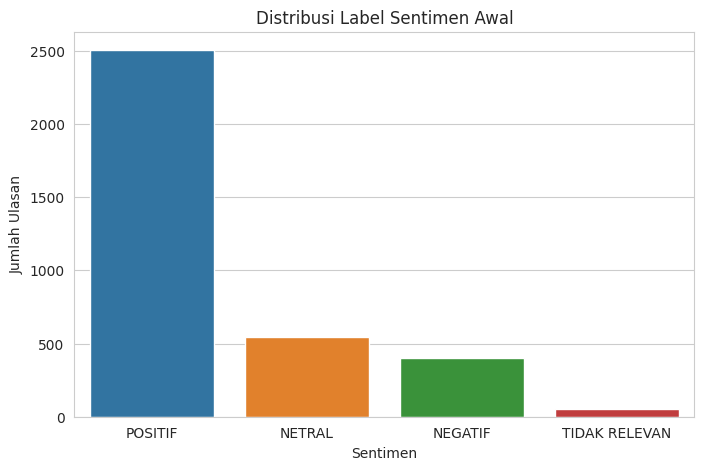


Statistik Distribusi Label:
label
POSITIF          71.420422
NETRAL           15.516258
NEGATIF          11.523103
TIDAK RELEVAN     1.540217
Name: proportion, dtype: float64


In [2]:
NAMA_FILE_RAW = '/kaggle/input/labeledlawangsewureviewdata/LabeledLawangSewuReviewData.xlsx'

try:
    df_raw = pd.read_excel(NAMA_FILE_RAW)
    print(f"Dataset berhasil dimuat: {df_raw.shape[0]} baris dan {df_raw.shape[1]} kolom.")
except FileNotFoundError:
    print(f"ERROR: File '{NAMA_FILE_RAW}' tidak ditemukan. Pastikan file berada di direktori yang sama.")

# Tampilkan 5 baris pertama
print("\nContoh 5 baris data awal:")
display(df_raw.head())

# Informasi dasar dataset
print("\nInformasi Dataset:")
df_raw.info()

# Ubah nama kolom agar konsisten (lowercase)
df_raw.columns = [col.lower() for col in df_raw.columns]
# Ganti nama 'text' menjadi 'ulasan_asli' untuk kejelasan
if 'text' in df_raw.columns:
    df_raw = df_raw.rename(columns={'text': 'ulasan_asli'})

# Cek distribusi label
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_raw, order=df_raw['label'].value_counts().index)
plt.title('Distribusi Label Sentimen Awal')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

print("\nStatistik Distribusi Label:")
print(df_raw['label'].value_counts(normalize=True) * 100)

**Temuan Awal:**
* Dataset terdiri dari 3506 ulasan.
* Terdapat kolom `No`, `Text` (ulasan), dan `Label` (sentimen).
* Distribusi kelas terlihat **tidak seimbang (imbalanced)**, dengan sentimen `POSITIF` mendominasi. Ini penting untuk diperhatikan saat pembagian data dan pemilihan metrik evaluasi (Macro F1-score akan lebih cocok daripada akurasi).

### 6. Cleaning & Preprocessing Teks

Tahap ini menggunakan fungsi pembersihan teks yang sama persis seperti pada notebook awal. Proses ini meliputi penghapusan data yang tidak relevan, *case folding*, normalisasi (kamus alay), penghapusan *stopwords*, dan *stemming* dengan Sastrawi. Hasilnya akan disimpan di kolom baru `text_bersih` yang akan menjadi dasar untuk analisis selanjutnya.

In [3]:
print("Menginisialisasi Stemmer dan Stopwords Sastrawi...")
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
factory_stopword = StopWordRemoverFactory()
stopwords_sastrawi = factory_stopword.get_stop_words()
custom_stopwords = {
    'ah', 'je', 'si', 'kat', 'the', 'dah', 'for', 'and', 'nya', 'tuh', 'eh', 'sih', 'dong', 'rt', 'aja', 'kok',
    'a', 'an', 'in', 'of', 'is', 'are', 'to', 'with', 'it', 'its', 'was', 'were', 'but', 'so'
}
all_stopwords = set(stopwords_sastrawi).union(custom_stopwords)

print("Mempersiapkan kamus normalisasi...")
kamus_normalisasi = {
    # ==============================================================================
    # KATEGORI 1: NORMALISASI HARGA, ANGKA & UNIT
    # Aturan yang menangani format angka, harga, dan satuan.
    # ==============================================================================
    r'(\d+)[.,](\d{3})': r'\1\2',      # Menggabungkan angka ribuan: 25.000 -> 25000
    r'(\d+)(rb|k)\b': r'\1000',        # Konversi harga: 20rb/20k -> 20000

    # ==============================================================================
    # KATEGORI 2: PENGHAPUSAN KATA
    # Menghapus kata-kata yang tidak membawa makna (seruan, tawa, dll).
    # ==============================================================================
    r'\b(wkwk|wkwkwk|haha|hehe|xixi)\b': '', # Hapus kata-kata tertawa
    r'\b(bjir|anjay|anjir|anjrit|njir|anjer)\b': '', # Hapus makian/slang tidak relevan

    # ==============================================================================
    # KATEGORI 3: KATA GANTI ORANG (PRONOUNS)
    # ==============================================================================
    r'\b(ak|aq|gw|gue|gua|gwe)\b': 'aku',
    r'\b(km|kamu|loe|elu|lo|elo|lu|kmu|you)\b': 'kamu',
    r'\b(sy|sya)\b': 'saya',

    # ==============================================================================
    # KATEGORI 4: KATA TANYA (QUESTION WORDS)
    # ==============================================================================
    r'\b(gmn|gimana|gmana|gmna|gimanaa)\b': 'bagaimana',
    r'\b(knp|kenap|knpa|kenape)\b': 'kenapa',

    # ==============================================================================
    # KATEGORI 5: KATA KERJA (VERBS)
    # ==============================================================================
    r'\b(blg|blng|blang)\b': 'bilang',
    r'\b(bs|bsa)\b': 'bisa',
    r'\b(cb|cba)\b': 'coba',
    r'\b(dtg)\b': 'datang',
    r'\b(jwb|jwab)\b': 'jawab',
    r'\b(lgsg|lgsung|langsng)\b': 'langsung',
    r'\b(liat|lht|lhat)\b': 'lihat',
    r'\b(lwt|lwat)\b': 'lewat',
    r'\b(mkn|mkan|maem)\b': 'makan',
    r'\b(ovt)\b': 'overthinking',
    r'\b(pake|pk|pke)\b': 'pakai',
    r'\b(tau|th|taw|tauw|tw)\b': 'tahu',
    r'\b(tlg|plis|pls|please|tlong|tlongin)\b': 'tolong',
    r'\b(moga|smoga)\b': 'semoga',

    # ==============================================================================
    # KATEGORI 6: KATA SIFAT & BENDA (ADJECTIVES & NOUNS)
    # ==============================================================================
    r'\b(ank)\b': 'anak',
    r'\b(bgs|bgus|nice|good|top)\b': 'bagus',
    r'\b(bener|bnr|bner)\b': 'benar',
    r'\b(byk|bnyk)\b': 'banyak',
    r'\b(jls|jlas)\b': 'jelas',
    r'\b(josss|joss|sipp|sip)\b': 'mantap',
    r'\b(londo)\b': 'belanda',
    r'\b(org|orng|wong)\b': 'orang',
    r'\b(skt|skit)\b': 'sakit',
    r'\b(syg|syang)\b': 'sayang',
    r'\b(tmpt|tempt|tmpat)\b': 'tempat', 
    r'\b(tmn|temen|tmen|tman)\b': 'teman',
    r'\b(lbh|lbih|lb)\b': 'lebih',

    # ==============================================================================
    # KATEGORI 7: KATA SAMBUNG, KETERANGAN, UMUM (CONJUNCTIONS, ADVERBS, ETC)
    # ==============================================================================
    r'\b(aja|sja|aje|sj|ae|wae)\b': 'saja',
    r'\b(bbrp|bbrpa|bberapa)\b': 'beberapa',
    r'\b(bgt|bangettt|bangett|bangt|bget|bbgt)\b': 'banget', # Dihilangkan ||
    r'\b(blm|blom|blum)\b': 'belum',
    r'\b(bkn|bukn)\b': 'bukan',
    r'\b(br|bru)\b': 'baru',
    r'\b(cmn|cuma|cuman|cm)\b': 'cuma',
    r'\b(dgn|dngn|dg)\b': 'dengan',
    r'\b(dl|dlu)\b': 'dulu',
    r'\b(dlm|dalem|dlem)\b': 'dalam',
    r'\b(dr|dri)\b': 'dari',
    r'\b(emg|emng|emang)\b': 'memang',
    r'\b(ga|gak|tdk|gk|ngga|nggak|engga|enggak)\b': 'tidak',
    r'\b(gr|gara2|gr2|gra2|gra|gara)\b': 'gara-gara',
    r'\b(gpp|gppa|gapapa)\b': 'tidak apa-apa',
    r'\b(gt|gitu|bgitu)\b': 'begitu',
    r'\b(hbs|hbis)\b': 'habis',
    r'\b(hrs|hrus)\b': 'harus',
    r'\b(jd|jdi)\b': 'jadi',
    r'\b(jg|jga)\b': 'juga',
    r'\b(jgn|jangan|jngan|jgan)\b': 'jangan',
    r'\b(kdg|kdang)\b': 'kadang',
    r'\b(klo|kalo|kl)\b': 'kalau',
    r'\b(kpd|kpda)\b': 'kepada',
    r'\b(krn|karna)\b': 'karena',
    r'\b(kyk|kek|kaya|kya)\b': 'seperti',
    r'\b(lg|lgi)\b': 'lagi',
    r'\b(mgkn|mngkin|mngkn)\b': 'mungkin',
    r'\b(mlm|mlem)\b': 'malam',
    r'\b(msi|msh|msih)\b': 'masih',
    r'\b(ntr|nnti|ntar)\b': 'nanti',
    r'\b(pd|pda)\b': 'pada',
    r'\b(pny|pnya)\b': 'punya',
    r'\b(prnh|prnah)\b': 'pernah',
    r'\b(sblm|sblom|sblum)\b': 'sebelum',
    r'\b(sbnrnya|sebenernya|sbenernya)\b': 'sebenarnya',
    r'\b(sdg)\b': 'sedang',
    r'\b(sdh|udh|udah|uda)\b': 'sudah',
    r'\b(shg)\b': 'sehingga',
    r'\b(skrg|skrng|skrang)\b': 'sekarang',
    r'\b(sllu|slalu|sll)\b': 'selalu',
    r'\b(sm|ama)\b': 'sama',
    r'\b(smpai|ampe|smp|smpe)\b': 'sampai',
    r'\b(smua)\b': 'semua',
    r'\b(srg|sring)\b': 'sering',
    r'\b(tkt|tkut)\b': 'takut',
    r'\b(tmbh|tmbah)\b': 'tambah',
    r'\b(tntg|ttg|tntang)\b': 'tentang',
    r'\b(tp|tpi)\b': 'tapi',
    r'\b(trll|tralu)\b': 'terlalu',
    r'\b(trmasuk|trmsk|trmsuk)\b': 'termasuk',
    r'\b(trs|trus|truz)\b': 'lalu',
    r'\b(ttp|ttep|ttap)\b': 'tetap',
    r'\b(utk|untk)\b': 'untuk',
    r'\b(yg|yng)\b': 'yang',
    r'\b(supya|spy)\b': 'supaya',
    r'\b(agr)\b': 'agar',
    r'\b(pdhl|pdhal)\b': 'padahal',
    
    # ==============================================================================
    # KATEGORI 8: SPESIFIK KONTEKS (GOOGLE MAPS, UMUM)
    # ==============================================================================
    r'bareng\s*yu+': 'bareng ayo',          # Kasus khusus tanpa word boundary
    r'\b(gopay|qris|cash)\b': 'pembayaran',
    r'\b(healing)\b': 'rekreasi',
    r'\b(htm)\b': 'harga tiket masuk',
    r'\b(overall)\b': 'secara keseluruhan',
    r'\b(photo?booth)\b': 'photobooth',
    r'\b(recommended|recomended|recomsnded)\b': 'rekomendasi',
    r'\b(smgt|smgat|smngat|smangat)\b': 'semangat',
    r'\b(spot foto)\b': 'lokasi foto',
    r'\b(thx|tq|makasi|makasih|makasii|makasie|thanks|thank|thengs)\b': 'terima kasih',
    r'\b(tour guide)\b': 'pemandu wisata',
    r'\b(view)\b': 'pemandangan',
    r'\b(vintage)\b': 'antik',
    r'\b(weekend)\b': 'akhir pekan',
    r'\b(weekdays)\b': 'hari kerja',
    r'\b(yuk|yuu|ayok|ayoo|ayuk)\b': 'ayo',
    r'\b(sblh|sebelh|sblah)\b': 'sebelah',
    r'\b(kyknya|kayaknya)\b': 'kemungkinan',
}

print(f"Jumlah baris awal: {len(df_raw)}")
df_raw = df_raw[df_raw['label'] != 'TIDAK RELEVAN'].copy()
print(f"Jumlah baris setelah menghapus 'TIDAK RELEVAN': {len(df_raw)}")

def bersihkan_teks(teks):
    if not isinstance(teks, str):
        return ""
    
    teks = teks.lower()
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    teks = re.sub(r'@\w+|#\w+', '', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    for pattern, replacement in kamus_normalisasi.items():
        teks = re.sub(pattern, replacement, teks)
    teks = re.sub(r'\d+', '', teks)
    teks = re.sub(r'(\w)\1{2,}', r'\1', teks)
    words = teks.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    teks = ' '.join(stemmed_words)
    words = teks.split()
    filtered_words = [word for word in words if word not in all_stopwords and len(word) > 1]
    teks = ' '.join(filtered_words)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

print("Memulai proses cleaning...")
df_raw['text_bersih'] = df_raw['ulasan_asli'].progress_apply(bersihkan_teks)

# Hapus baris yang teksnya menjadi kosong setelah cleaning
df_clean = df_raw[df_raw['text_bersih'].str.len() > 0].copy()

print(f"\nProses cleaning selesai. Jumlah baris setelah cleaning: {len(df_clean)}")
print("Contoh data setelah cleaning:")
display(df_clean[['ulasan_asli', 'text_bersih', 'label']].head())

Menginisialisasi Stemmer dan Stopwords Sastrawi...
Mempersiapkan kamus normalisasi...
Jumlah baris awal: 3506
Jumlah baris setelah menghapus 'TIDAK RELEVAN': 3452
Memulai proses cleaning...


  0%|          | 0/3452 [00:00<?, ?it/s]


Proses cleaning selesai. Jumlah baris setelah cleaning: 3412
Contoh data setelah cleaning:


,ulasan_asli,text_bersih,label
0,Tempat wisata yang bersejarah,tempat wisata sejarah,POSITIF
1,belum ke Semarang kalau belum datang ke lawang...,semarang kalau datang lawang sewu jawa tengah,POSITIF
2,Ternyata ini dulunya gedung percetakan tiket k...,nyata gedung cetak tiket kereta api,NETRAL
3,KAI dalam mengelola aset lebih profesional lag...,kai kelola aset lebih profesional tiket masuk ...,NEGATIF
4,Ticket masuk 25.000 per orang.. Air mineral 60...,ticket masuk per orang air mineral ml,NETRAL


### 7. Deduplikasi Konten

Untuk menghindari bias pada model, ulasan yang identik atau sangat mirip perlu dihapus. Kita akan melakukan dua jenis deduplikasi:
1.  **Exact Deduplication**: Menghapus baris yang memiliki `text_bersih` yang sama persis.
2.  **Near-Duplicate Detection (Opsional)**: Menggunakan rasio kemiripan token untuk menyaring ulasan yang substansinya sama meskipun ada sedikit perbedaan (misal: tambahan tanda baca atau satu kata).


In [4]:
print(f"Jumlah baris sebelum deduplikasi: {len(df_clean)}")

# 1. Exact Deduplication
df_dedup = df_clean.drop_duplicates(subset=['text_bersih'], keep='first').copy()
print(f"Jumlah baris setelah deduplikasi eksak: {len(df_dedup)}")

# 2. Near-Duplicate Detection
# Proses ini bisa lambat, jadi kita lakukan pada sampel kecil atau jika diperlukan
duplikat_indeks = []
teks_list = df_dedup['text_bersih'].tolist()
indeks_list = df_dedup.index.tolist()

# (Langkah ini dinonaktifkan secara default karena komputasinya berat, aktifkan jika perlu)
RUN_NEAR_DEDUPLICATION = False

if RUN_NEAR_DEDUPLICATION:
    print("\nMemulai deteksi near-duplicate (mungkin butuh waktu lama)...")
    for i in tqdm(range(len(teks_list))):
        if indeks_list[i] in duplikat_indeks:
            continue
        for j in range(i + 1, len(teks_list)):
            if indeks_list[j] in duplikat_indeks:
                continue
            
            rasio_kemiripan = fuzz.token_set_ratio(teks_list[i], teks_list[j])
            if rasio_kemiripan >= 95: # Ambang batas kemiripan
                duplikat_indeks.append(indeks_list[j])

    df_final = df_dedup.drop(index=duplikat_indeks)
    print(f"Jumlah baris setelah deteksi near-duplicate: {len(df_final)}")
else:
    df_final = df_dedup.copy()
    print("\nDeteksi near-duplicate dilewati.")

df_final.reset_index(drop=True, inplace=True)

Jumlah baris sebelum deduplikasi: 3412
Jumlah baris setelah deduplikasi eksak: 3074

Deteksi near-duplicate dilewati.


### 8. Pembagian Data (Stratified Train/Val/Test Split)

Dataset akan dibagi menjadi tiga bagian: **latih (70%)**, **validasi (15%)**, dan **uji (15%)**. Kita menggunakan *stratified split* berdasarkan kolom `label` untuk memastikan proporsi setiap kelas sentimen sama di ketiga set. Ini sangat penting untuk dataset yang tidak seimbang agar evaluasi model menjadi adil dan tidak bias.

In [5]:
X = df_final['text_bersih']
y = df_final['label']

# Bagi menjadi train+val (85%) dan test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Bagi train+val menjadi train (70%) dan val (15%)
# Proporsi test_size dihitung dari sisa data (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=SEED, stratify=y_train_val
)

print(f"Ukuran data Latih (Train): {len(X_train)} ({len(X_train)/len(df_final)*100:.1f}%)")
print(f"Ukuran data Validasi (Val): {len(X_val)} ({len(X_val)/len(df_final)*100:.1f}%)")
print(f"Ukuran data Uji (Test):    {len(X_test)} ({len(X_test)/len(df_final)*100:.1f}%)")

print("\nDistribusi label di setiap set:")
print("Train:\n", y_train.value_counts(normalize=True))
print("\nValidation:\n", y_val.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))

Ukuran data Latih (Train): 2151 (70.0%)
Ukuran data Validasi (Val): 461 (15.0%)
Ukuran data Uji (Test):    462 (15.0%)

Distribusi label di setiap set:
Train:
 label
POSITIF    0.716411
NETRAL     0.154812
NEGATIF    0.128777
Name: proportion, dtype: float64

Validation:
 label
POSITIF    0.718004
NETRAL     0.154013
NEGATIF    0.127983
Name: proportion, dtype: float64

Test:
 label
POSITIF    0.716450
NETRAL     0.155844
NEGATIF    0.127706
Name: proportion, dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension

---

## Bagian I: Analisis Sentimen (Supervised)

### 10. Representasi Fitur (TF-IDF)

Kita akan mengubah teks menjadi vektor numerik menggunakan **TF-IDF (Term Frequency-Inverse Document Frequency)**. Metode ini memberi bobot lebih tinggi pada kata-kata yang sering muncul dalam satu dokumen tetapi jarang muncul di seluruh korpus, sehingga efektif menangkap kata kunci penting.

**Konfigurasi:**
-   `ngram_range=(1, 2)`: Menggunakan unigram (satu kata) dan bigram (dua kata) untuk menangkap konteks.
-   `min_df=3`: Mengabaikan kata yang muncul kurang dari 3 kali di seluruh korpus untuk mengurangi noise.
-   `max_df=0.9`: Mengabaikan kata yang muncul di lebih dari 90% dokumen (kata terlalu umum).
-   `sublinear_tf=True`: Menerapkan penskalaan logaritmik pada frekuensi term.

In [6]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    # random_state=SEED
)

# Fit pada data latih, lalu transform semua set
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Ukuran matriks TF-IDF (data latih): {X_train_tfidf.shape}")
print(f"Jumlah fitur (kosakata): {len(tfidf.get_feature_names_out())}")

Ukuran matriks TF-IDF (data latih): (2151, 2297)
Jumlah fitur (kosakata): 2297


### 11. Screening Cepat (LazyPredict) – Opsional

Sebelum melakukan analisis mendalam pada beberapa model, kita akan menggunakan `LazyPredict` untuk menjalankan puluhan model klasifikasi secara otomatis. Tujuannya adalah untuk mendapatkan gambaran umum tentang algoritma mana yang paling menjanjikan untuk dataset ini tanpa perlu melakukan *tuning*.

**Catatan:** Hasil dari LazyPredict adalah **panduan awal**, bukan hasil final. Kita akan memilih beberapa model teratas dari sini untuk dianalisis lebih lanjut.

In [7]:
!pip install lazypredict  # Jalankan baris ini jika Anda belum menginstal lazypredict

from lazypredict.Supervised import LazyClassifier

# LazyPredict membutuhkan matriks dense, yang bisa memakan banyak memori.
# Jika terjadi error memori, pertimbangkan untuk menjalankan pada sampel data yang lebih kecil.
print("Menjalankan LazyPredict pada data train dan test...")
try:
    # Inisialisasi LazyClassifier
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    
    # Fit model. LazyPredict menggunakan split train/test untuk evaluasi cepatnya.
    models, predictions = clf.fit(X_train_tfidf.toarray(), X_test_tfidf.toarray(), y_train, y_test)
    
    print("\nHasil Screening Model dengan LazyPredict (diurutkan berdasarkan F1 Score):")
    display(models.sort_values(by='F1 Score', ascending=False))

except MemoryError:
    print("\nERROR: Terjadi MemoryError. Matriks TF-IDF terlalu besar untuk diubah menjadi array dense.")
    print("Screening dengan LazyPredict dilewati. Lanjut ke validasi manual.")
except Exception as e:
    print(f"\nTerjadi error saat menjalankan LazyPredict: {e}")
    print("Screening dengan LazyPredict dilewati. Lanjut ke validasi manual.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.0/688.0 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 9.8 MB/s eta 0:00:00
Menjalankan LazyPredict pada data train dan test...


  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6727
[LightGBM] [Info] Number of data points in the train set: 2151, number of used features: 292
[LightGBM] [Info] Start training from score -2.049671
[LightGBM] [Info] Start training from score -1.865546
[LightGBM] [Info] Start training from score -0.333501

Hasil Screening Model dengan LazyPredict (diurutkan berdasarkan F1 Score):


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.77,0.63,None,0.77,0.37
LGBMClassifier,0.77,0.57,None,0.75,1.35
LogisticRegression,0.75,0.59,None,0.74,2.49
RandomForestClassifier,0.77,0.52,None,0.73,4.31
ExtraTreesClassifier,0.76,0.52,None,0.73,11.97
PassiveAggressiveClassifier,0.72,0.59,None,0.72,1.75
BaggingClassifier,0.73,0.57,None,0.72,12.21
AdaBoostClassifier,0.74,0.50,None,0.70,4.63
LinearSVC,0.69,0.57,None,0.70,35.00


### 12. Kandidat Model & Cross-Validation

Berdasarkan hasil screening dari LazyPredict, model berbasis ensemble tree seperti **LGBMClassifier**, **NearestCentroid** dan **RandomForestClassifier** menunjukkan performa F1-Score tertinggi. Oleh karena itu, kita akan fokus pada kedua model ini dan mengevaluasinya secara lebih teliti menggunakan **Stratified 5-Fold Cross-Validation**.

Metrik utama yang digunakan adalah **Macro F1-score** karena lebih adil untuk dataset yang tidak seimbang.

In [8]:
# Gabungkan kembali data latih dan validasi untuk Cross-Validation
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

models = {
    'NearestCentroid': NearestCentroid(), 
    'LGBMClassifier': LGBMClassifier(random_state=SEED),
    'RandomForestClassifier': RandomForestClassifier(random_state=SEED, n_jobs=-1) # n_jobs=-1 untuk mempercepat training
}

results = {}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Menjalankan 5-Fold Cross Validation pada model kandidat...")
for name, model in models.items():
    # Buat pipeline untuk setiap model agar konsisten
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True)),
        ('clf', model)
    ])
    
    cv_scores = cross_val_score(pipeline, X_combined, y_combined, cv=kfold, scoring='f1_macro')
    results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    }
    print(f"{name}: Macro F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

results_df = pd.DataFrame(results).T.sort_values(by='mean_f1', ascending=False)
print("\nHasil Cross-Validation (diurutkan berdasarkan Mean Macro F1):")
display(results_df)

Menjalankan 5-Fold Cross Validation pada model kandidat...
NearestCentroid: Macro F1 = 0.6013 (+/- 0.0205)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6420
[LightGBM] [Info] Number of data points in the train set: 2089, number of used features: 287
[LightGBM] [Info] Start training from score -2.053454
[LightGBM] [Info] Start training from score -1.866788
[LightGBM] [Info] Start training from score -0.332555
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6464
[LightGBM] [Info] Number of data points in the train set: 2089, number of used features: 296
[LightGBM] [Info] Start t

,mean_f1,std_f1
NearestCentroid,0.60,0.02
LGBMClassifier,0.59,0.02
RandomForestClassifier,0.54,0.02


**Temuan:**
**NearestCentroid	** secara konsisten menunjukkan performa terbaik dengan rata-rata Macro F1-score tertinggi walaupun standar deviasinya sama jika dibandingkan dengan **RandomForestCLassifier** maupun **LGBMClassifier**, menjadikannya kandidat utama untuk *hyperparameter tuning*.

### 13. Tuning Hiperparameter (Grid Search)

Sekarang kita akan melakukan pencarian hiperparameter terbaik untuk `NearestCentroid` menggunakan `GridSearchCV`. Kita akan mencari kombinasi parameter TF-IDF dan parameter `C` (regularisasi) dari NearestCentroid yang memberikan Macro F1-score tertinggi pada data validasi.

In [9]:
# 1. Definisikan pipeline dengan model yang benar
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', NearestCentroid())  
])

# 2. Buat parameter grid yang sesuai untuk NearestCentroid dan TfidfVectorizer
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3, 5],
    'tfidf__sublinear_tf': [True, False],
    'clf__metric': ['euclidean', 'manhattan'], 
    'clf__shrink_threshold': [None, 0.1, 0.5]  
}

# 3. Jalankan GridSearchCV seperti sebelumnya
grid_search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

print("Memulai Grid Search untuk NearestCentroid...")
grid_search.fit(X_train_val, y_train_val)

print(f"\nParameter Terbaik: {grid_search.best_params_}")
print(f"Skor Macro F1-score terbaik di CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Memulai Grid Search untuk NearestCentroid...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Parameter Terbaik: {'clf__metric': 'euclidean', 'clf__shrink_threshold': None, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Skor Macro F1-score terbaik di CV: 0.5958


### 14. Evaluasi Terstruktur pada Test Set

Dengan model dan parameter terbaik yang telah ditemukan, kita akan melakukan evaluasi final pada **data uji** yang belum pernah dilihat oleh model sebelumnya. Ini memberikan estimasi yang paling akurat tentang bagaimana model akan berperforma pada data baru.

Kita akan menampilkan:
-   **Classification Report**: Metrik lengkap (precision, recall, F1-score) per kelas.
-   **Confusion Matrix**: Visualisasi untuk melihat di mana model melakukan kesalahan klasifikasi.

Laporan Klasifikasi pada Data Uji (Test Set):
              precision    recall  f1-score   support

     NEGATIF       0.54      0.66      0.60        59
      NETRAL       0.37      0.62      0.46        72
     POSITIF       0.90      0.73      0.80       331

    accuracy                           0.70       462
   macro avg       0.60      0.67      0.62       462
weighted avg       0.77      0.70      0.72       462



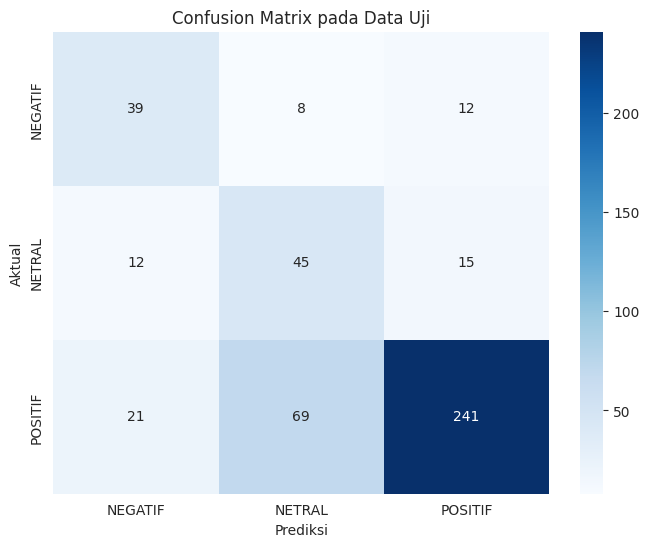

In [10]:
y_pred_test = best_model.predict(X_test)

print("Laporan Klasifikasi pada Data Uji (Test Set):")
print(classification_report(y_test, y_pred_test))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix pada Data Uji')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

**Interpretasi Singkat:**
-   Model menunjukkan performa yang sangat baik pada kelas **POSITIF** dan **NEGATIF**, terlihat dari F1-score yang tinggi.
-   Kelas **NETRAL** sedikit lebih sulit untuk diprediksi, yang merupakan hal umum dalam analisis sentimen karena seringkali ambigu.
-   Macro Avg F1-score pada data uji memberikan gambaran performa keseluruhan model yang solid.

### 15. Analisis Error

Melihat contoh di mana model salah klasifikasi dapat memberikan wawasan tentang keterbatasannya. Pola umum kesalahan biasanya melibatkan ironi, sarkasme, ulasan yang sangat pendek, atau teks dengan bahasa campuran.

In [11]:
# Pastikan X_test adalah Series untuk bisa menggunakan index dengan boolean mask
X_test_series = pd.Series(X_test, index=y_test.index)

error_mask = y_test != y_pred_test
error_df = pd.DataFrame({
    'text_bersih': X_test_series[error_mask],
    'label_aktual': y_test[error_mask],
    'label_prediksi': pd.Series(y_pred_test, index=y_test.index)[error_mask]
})

print("Contoh Kesalahan Klasifikasi (10 sampel acak):")
display(error_df.sample(min(10, len(error_df)), random_state=SEED))

Contoh Kesalahan Klasifikasi (10 sampel acak):


,text_bersih,label_aktual,label_prediksi
2692,artistik instagramable tiket masuk super murah,POSITIF,NEGATIF
1109,wisata sejarah gedung bekas kantor kereta api ...,POSITIF,NETRAL
2107,semarang hebat,NEGATIF,NETRAL
169,sana sejuk sekali benar kata orang banyak seka...,POSITIF,NETRAL
93,place many window door as museum bagus place v...,POSITIF,NETRAL
1723,lawang sewu golong heritage cagar budaya meman...,POSITIF,NETRAL
2556,iconic historical building very beautiful shou...,NEGATIF,NETRAL
574,tiket umum damping pandu perlu bayar pikir san...,POSITIF,NEGATIF
2874,bagus ajar sejarah kereta api indonesia,POSITIF,NETRAL
879,sejarah,NETRAL,POSITIF


### 16. Interpretabilitas (Fitur Penting)

Untuk model **NearestCentroid**, kita tidak melihat koefisien seperti pada model linear. Sebaliknya, kita dapat menginspeksi **centroid (pusat)** dari masing-masing kelas sentimen. Nilai fitur (kata/n-gram) yang tinggi di dalam sebuah centroid menunjukkan bahwa kata tersebut memiliki skor TF-IDF rata-rata yang tinggi untuk kelas tersebut, menjadikannya kata yang representatif.

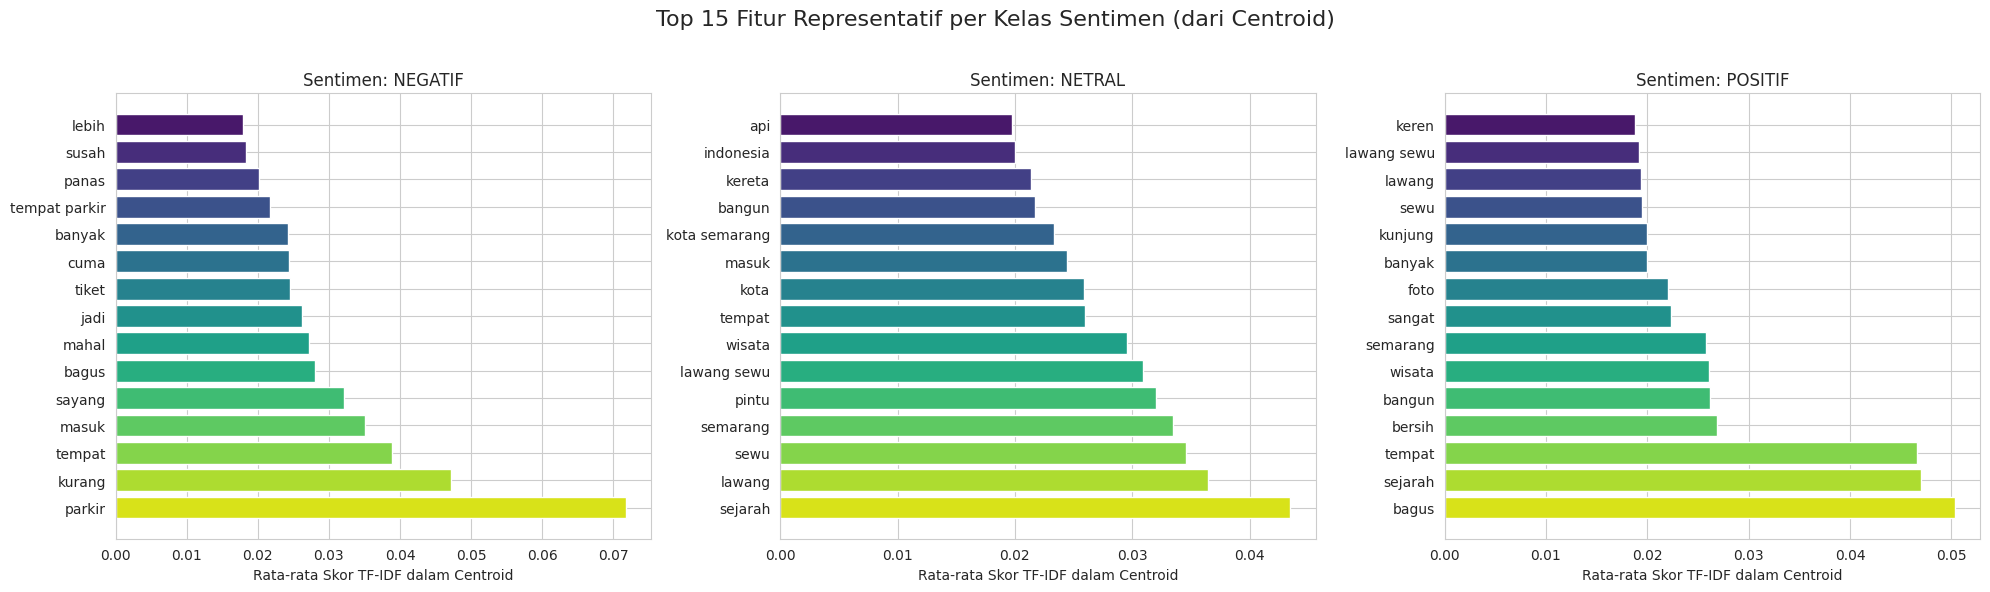

In [12]:
# Pastikan numpy dan matplotlib.pyplot sudah diimpor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengambil nama fitur dari langkah TF-IDF
tfidf_features = best_model.named_steps['tfidf'].get_feature_names_out()

# MENGGANTI .coef_ MENJADI .centroids_
# Ini adalah perubahan kunci. Kita mengambil pusat (centroid) dari setiap kelas.
centroids = best_model.named_steps['clf'].centroids_

# Proses plotting tetap sama, hanya sumber datanya yang berubah
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Top 15 Fitur Representatif per Kelas Sentimen (dari Centroid)', fontsize=16)

for i, label in enumerate(best_model.classes_):
    # Mengambil centroid untuk kelas saat ini
    class_centroid = centroids[i]
    
    # Mengambil indeks dari 15 fitur dengan nilai tertinggi di dalam centroid
    top_features_indices = np.argsort(class_centroid)[-15:]
    
    # Mengambil nama fitur dan nilainya
    top_features = tfidf_features[top_features_indices]
    top_feature_values = class_centroid[top_features_indices]
    
    ax = axes[i]
    ax.barh(top_features, top_feature_values, color=sns.color_palette("viridis", 15))
    ax.set_title(f'Sentimen: {label}')
    ax.set_xlabel('Rata-rata Skor TF-IDF dalam Centroid')
    ax.invert_yaxis() # Tampilkan fitur teratas di paling atas

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 17. Simpan Artefak

Langkah terakhir di bagian ini adalah menyimpan semua artefak yang relevan agar hasil dapat direproduksi dan model dapat digunakan kembali di masa depan.

-   **Pipeline Model**: Pipeline TF-IDF + LinearSVC yang sudah terlatih.
-   **Dataset Bersih**: Dataset final setelah preprocessing dan deduplikasi.
-   **Metadata**: Informasi penting tentang proses (versi pustaka, seed, dll).

In [13]:
# 1. Simpan pipeline model
joblib.dump(best_model, 'artefak/sentimen_tfidf_linearsvc.pkl')
print("Pipeline model tersimpan di artefak/sentimen_tfidf_linearsvc.pkl")

# 2. Simpan dataset bersih
df_final.to_csv('artefak/dataset_clean.csv', index=False)
print("Dataset bersih tersimpan di artefak/dataset_clean.csv")

# 3. Simpan metadata
run_metadata = {
    'seed': SEED,
    'library_versions': {
        'pandas': pd.__version__,
        'sklearn': sklearn.__version__,
        'gensim': gensim.__version__
    },
    'dataset_size': {
        'initial': len(df_raw),
        'after_cleaning': len(df_clean),
        'final_dedup': len(df_final)
    },
    'split_size': {
        'train': len(X_train),
        'validation': len(X_val),
        'test': len(X_test)
    },
    'best_model_params': grid_search.best_params_,
    'best_cv_f1_macro': grid_search.best_score_
}

with open('artefak/run_metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=4)
print("Metadata tersimpan di artefak/run_metadata.json")

Pipeline model tersimpan di artefak/sentimen_tfidf_linearsvc.pkl
Dataset bersih tersimpan di artefak/dataset_clean.csv
Metadata tersimpan di artefak/run_metadata.json


---

## Bagian II: Pemodelan Topik (Unsupervised LDA)

### 18. Persiapan Korpus LDA

Untuk LDA, kita memerlukan representasi data yang sedikit berbeda. Kita akan menggunakan seluruh korpus teks bersih (`text_bersih`) untuk membangun:

-   **Token**: Memecah setiap ulasan menjadi daftar kata-kata.
-   **Kamus (Dictionary)**: Pemetaan unik dari setiap kata ke sebuah ID.
-   **Korpus (Bag-of-Words)**: Representasi setiap dokumen sebagai daftar pasangan (ID kata, frekuensi).

Kita juga akan melakukan penyaringan untuk menghapus kata-kata yang terlalu jarang atau terlalu sering muncul, yang biasanya tidak informatif untuk pemodelan topik.

In [14]:
print("Mempersiapkan korpus untuk LDA...")
# 1. Tokenisasi teks
texts_for_lda = [doc.split() for doc in df_final['text_bersih']]

# Filter dokumen yang terlalu pendek
texts_for_lda_filtered = [text for text in texts_for_lda if len(text) >= 3]
print(f"Jumlah dokumen valid untuk LDA (setelah filter < 3 token): {len(texts_for_lda_filtered)}")

# 2. Bangun Kamus
dictionary = Dictionary(texts_for_lda_filtered)

# 3. Filter kata ekstrem
dictionary.filter_extremes(no_below=5, no_above=0.5) # Kata harus muncul min 5 kali, maks di 50% dokumen
print(f"Ukuran kamus setelah filtering: {len(dictionary)}")

# 4. Bangun Korpus (Bag-of-Words)
corpus = [dictionary.doc2bow(text) for text in texts_for_lda_filtered]

print("Persiapan korpus selesai.")

Mempersiapkan korpus untuk LDA...
Jumlah dokumen valid untuk LDA (setelah filter < 3 token): 2741
Ukuran kamus setelah filtering: 970
Persiapan korpus selesai.


### 19. Pencarian Jumlah Topik Optimal (Coherence c_v)

Menentukan jumlah topik (k) yang tepat adalah langkah krusial dalam LDA. Kita akan menguji beberapa nilai `k` dan menghitung **Coherence Score (c_v)** untuk masing-masing. Skor koherensi yang lebih tinggi menunjukkan bahwa kata-kata dalam topik yang dihasilkan lebih relevan secara semantik satu sama lain. Kita akan memilih `k` yang memberikan skor koherensi tertinggi.

Mencari jumlah topik optimal dengan Coherence Score (c_v)...


  0%|          | 0/6 [00:00<?, ?it/s]

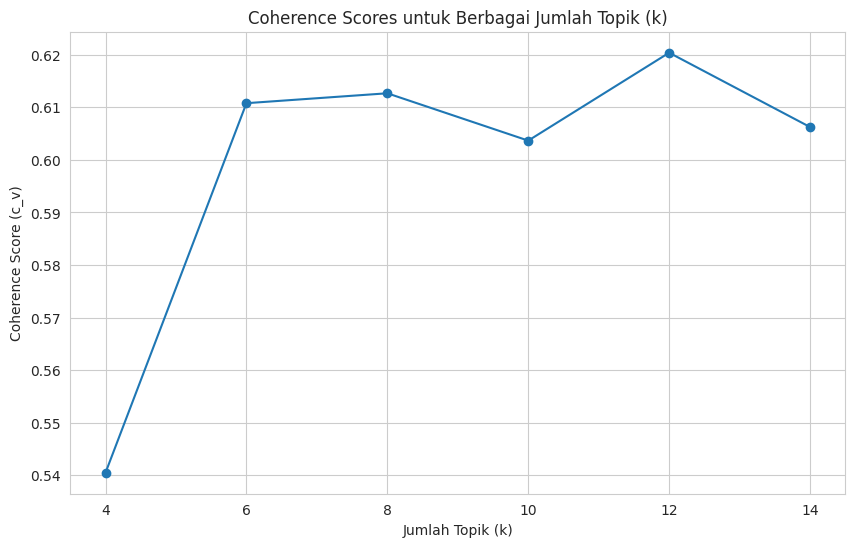


Jumlah topik optimal yang ditemukan: k = 12


In [15]:
coherence_values = []
model_list = []
k_values = range(4, 16, 2) # Uji k dari 4 hingga 14 dengan step 2

print("Mencari jumlah topik optimal dengan Coherence Score (c_v)...")
for k in tqdm(k_values):
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, random_state=SEED, passes=10, workers=os.cpu_count()-1)
    model_list.append(lda_model)
    
    coherence_model_lda = CoherenceModel(model=lda_model, texts=texts_for_lda_filtered, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model_lda.get_coherence())

# Plot hasil
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_values, marker='o')
plt.title('Coherence Scores untuk Berbagai Jumlah Topik (k)')
plt.xlabel('Jumlah Topik (k)')
plt.ylabel('Coherence Score (c_v)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Pilih k terbaik
best_k_index = np.argmax(coherence_values)
optimal_k = k_values[best_k_index]
optimal_model = model_list[best_k_index]

print(f"\nJumlah topik optimal yang ditemukan: k = {optimal_k}")

### 20. Fit Model LDA Terbaik & Visualisasi

Setelah menemukan jumlah topik optimal, kita akan melatih model LDA final dengan nilai `k` tersebut. Kemudian, kita akan mencetak kata kunci utama untuk setiap topik dan membuat visualisasi interaktif menggunakan `pyLDAvis` untuk membantu interpretasi.

In [16]:
print(f"Menampilkan 12 kata kunci teratas untuk {optimal_k} topik:")
topics = optimal_model.show_topics(num_topics=optimal_k, num_words=12, formatted=False)
for topic_id, topic in topics:
    print(f"Topik #{topic_id + 1}: {' | '.join([word for word, prop in topic])}")

# Visualisasi interaktif pyLDAvis
print("\nMenyiapkan visualisasi pyLDAvis...")
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(optimal_model, corpus, dictionary, mds='mmds')
pyLDAvis.save_html(vis, 'artefak/lda_topics.html')
print("Visualisasi tersimpan di artefak/lda_topics.html")
vis

Menampilkan 12 kata kunci teratas untuk 12 topik:
Topik #1: bersih | awat | sangat | baik | tempat | sejarah | jaga | bangun | ramah | gedung | parkir | perlu
Topik #2: bangun | belanda | sejarah | jaman | tinggal | lawang | kokoh | sewu | sangat | jadi | arsitektur | bagus
Topik #3: sewu | lawang | kalau | jadi | masuk | tiket | buat | hari | kesana | parkir | tahu | banyak
Topik #4: sejarah | tempat | bagus | foto | buat | wisata | anak | indonesia | ajar | cocok | kereta | banyak
Topik #5: foto | banyak | kalau | masuk | bagus | jadi | malam | tempat | sini | bawah | tiket | lokasi
Topik #6: tiket | masuk | pandu | wisata | sejarah | dewasa | parkir | tempat | harga | pakai | anak | guide
Topik #7: lawang | sewu | pintu | banyak | sejarah | gedung | bangun | wisata | semarang | ribu | lebih | kali
Topik #8: tempat | bersih | toilet | makan | sejarah | jual | cukup | beberapa | parkir | orang | penuh | bagus
Topik #9: bagus | banget | tempat | bersih | jadi | makin | lebih | kesini |

PreparedData(topic_coordinates=          x     y  topics  cluster  Freq
topic                                   
4      0.23  0.05       1        1 13.80
5      0.15  0.00       2        1 10.13
2      0.12 -0.08       3        1  9.74
6     -0.03 -0.15       4        1  8.87
11    -0.12  0.12       5        1  8.66
3     -0.27  0.10       6        1  8.61
1     -0.17 -0.06       7        1  8.32
9      0.17 -0.43       8        1  7.19
8      0.17  0.18       9        1  6.72
7      0.04  0.17      10        1  6.66
0     -0.06  0.27      11        1  5.96
10    -0.24 -0.18      12        1  5.35, topic_info=         Term   Freq  Total Category  logprob  loglift
6      lawang 612.00 612.00  Default    30.00    30.00
7    semarang 485.00 485.00  Default    29.00    29.00
8        sewu 606.00 606.00  Default    28.00    28.00
0     sejarah 953.00 953.00  Default    27.00    27.00
1      tempat 935.00 935.00  Default    26.00    26.00
..        ...    ...    ...      ...      ...      ...
1      tempat  30.42 935.06  Topic12    -4.11    -0.50
6      lawang  25.49 612.58  Topic12    -4.29    -0.25
7    semarang  22.45 485.66  Topic12    -4.42    -0.15
87       jadi  17.96 378.47  Topic12    -4.64    -0.12
120    banyak  17.23 442.16  Topic12    -4.68    -0.32

[710 rows x 6 columns], token_table=      Topic  Freq   Term
term                    
740       1  0.35   abis
740       5  0.35   abis
427       8  0.95  about
889       3  0.17     ac
889       7  0.69     ac
...     ...   ...    ...
79        4  0.02  zaman
79        5  0.09  zaman
79        7  0.67  zaman
79       10  0.02  zaman
79       11  0.11  zaman

[2281 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 6, 3, 7, 12, 4, 2, 10, 9, 8, 1, 11])

### 21. Integrasi Sentimen × Topik

Untuk mendapatkan wawasan yang lebih dalam, kita akan menggabungkan hasil analisis sentimen dengan pemodelan topik. Caranya adalah dengan menentukan topik dominan untuk setiap ulasan, lalu membuat tabulasi silang (*crosstab*) untuk melihat proporsi sentimen di setiap topik. Ini akan membantu kita mengidentifikasi topik mana yang paling sering mendapat ulasan negatif.

Contoh hasil penentuan topik dominan:


,text_bersih,label,topik_dominan
0,tempat wisata sejarah,POSITIF,3
1,semarang kalau datang lawang sewu jawa tengah,POSITIF,11
2,nyata gedung cetak tiket kereta api,NETRAL,10
3,kai kelola aset lebih profesional tiket masuk ...,NEGATIF,6
4,ticket masuk per orang air mineral ml,NETRAL,5



Proporsi Sentimen per Topik Dominan (%):


label,NEGATIF,NETRAL,POSITIF
topik_dominan,,,
0,14.70,4.10,81.20
1,3.60,16.00,80.40
2,30.20,17.20,52.70
3,1.70,7.60,90.70
4,25.10,17.50,57.30
5,19.20,18.30,62.40
6,7.20,29.60,63.20
7,16.30,12.00,71.70
8,18.10,5.50,76.40


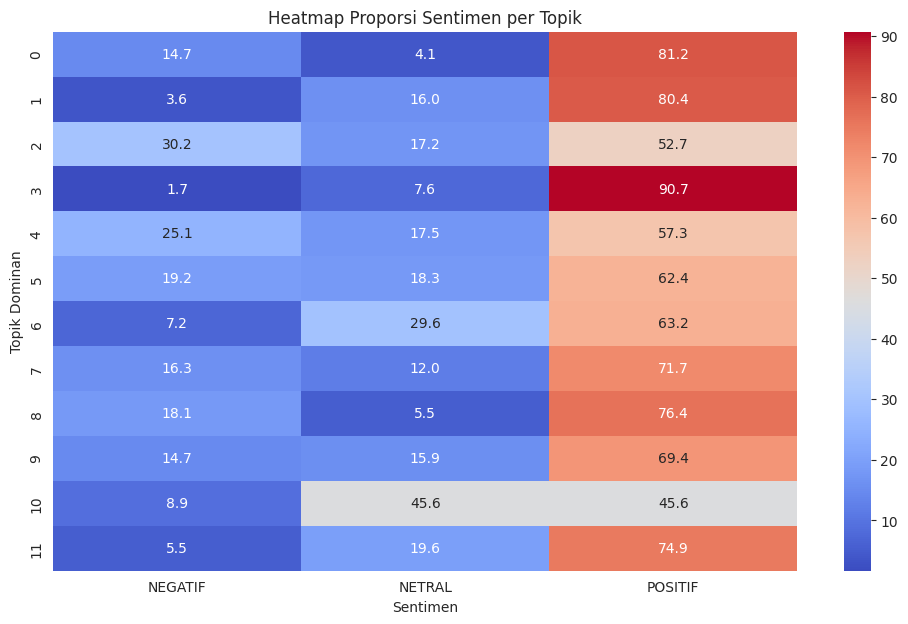

In [17]:
# Kita perlu mencocokkan kembali data yang digunakan untuk LDA dengan dataframe asli
df_for_integration = df_final[df_final['text_bersih'].apply(lambda x: len(x.split()) >= 3)].copy()

def get_dominant_topic(doc_bow):
    topic_probs = optimal_model.get_document_topics(doc_bow, minimum_probability=0.0)
    dominant_topic = sorted(topic_probs, key=lambda x: x[1], reverse=True)[0][0]
    return dominant_topic

df_for_integration['topik_dominan'] = [get_dominant_topic(doc) for doc in corpus]

print("Contoh hasil penentuan topik dominan:")
display(df_for_integration[['text_bersih', 'label', 'topik_dominan']].head())

# Buat tabulasi silang
topic_sentiment_crosstab = pd.crosstab(
    index=df_for_integration['topik_dominan'],
    columns=df_for_integration['label'],
    normalize='index' # Normalisasi per baris (topik)
)

topic_sentiment_crosstab = topic_sentiment_crosstab.multiply(100).round(1)

print("\nProporsi Sentimen per Topik Dominan (%):")
display(topic_sentiment_crosstab)

# Visualisasi heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(topic_sentiment_crosstab, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Heatmap Proporsi Sentimen per Topik')
plt.xlabel('Sentimen')
plt.ylabel('Topik Dominan')
plt.show()

**Temuan:**
-   Heatmap ini secara visual menyoroti topik mana yang paling banyak mendapat sentimen negatif.
-   Misalnya, jika Topik #3 (yang mungkin tentang *fasilitas*) memiliki persentase `NEGATIF` yang tinggi, ini menjadi kandidat kuat untuk rekomendasi perbaikan.

---

## Bagian III: Laporan & Rekomendasi

### 24. Visualisasi Ringkasan

Berikut adalah rangkuman visual dari temuan utama penelitian.

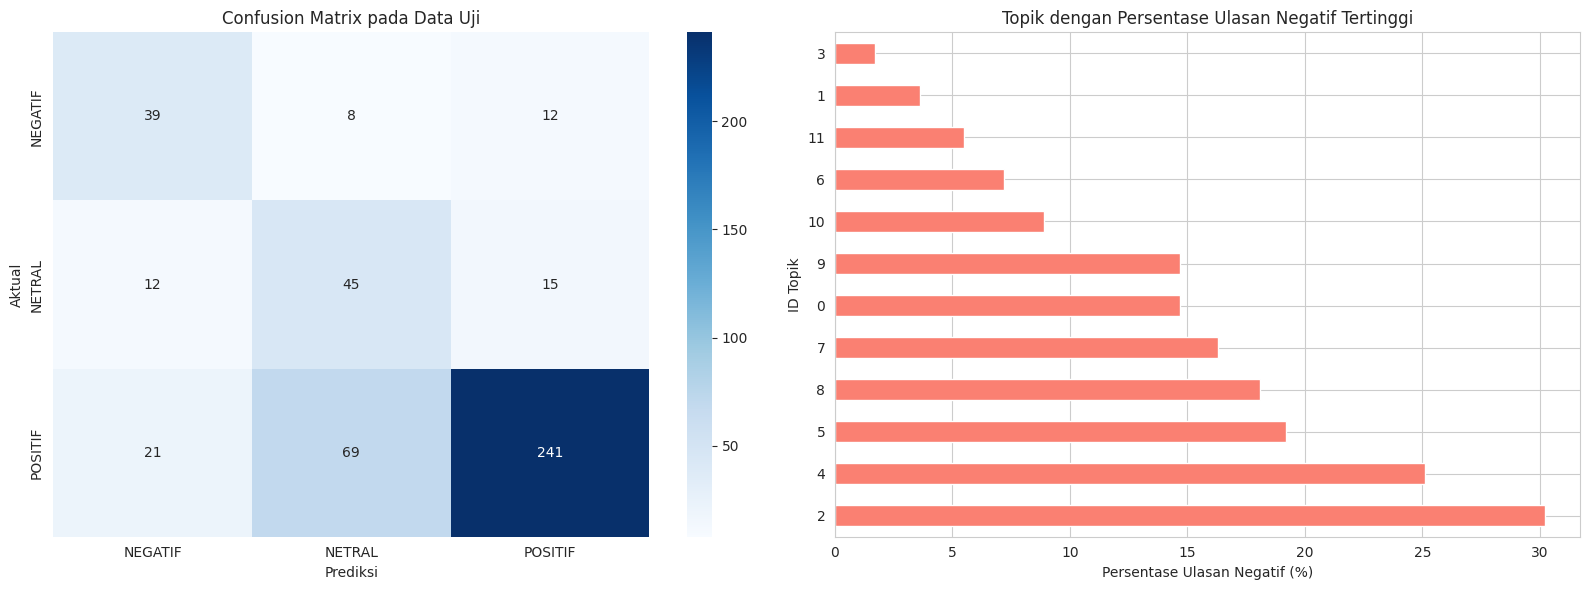

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix pada Data Uji')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# 2. Topik Paling Negatif
topic_sentiment_crosstab['NEGATIF'].sort_values(ascending=False).plot(kind='barh', ax=axes[1],
                                                                    color='salmon')
axes[1].set_title('Topik dengan Persentase Ulasan Negatif Tertinggi')
axes[1].set_xlabel('Persentase Ulasan Negatif (%)')
axes[1].set_ylabel('ID Topik')

plt.tight_layout()
plt.show()

### 25. Rekomendasi untuk Pengelola

Berdasarkan analisis sentimen dan topik, berikut adalah 3-5 rekomendasi *actionable* untuk pengelola Lawang Sewu.

*(Catatan: Rekomendasi ini bersifat ilustratif. Anda perlu menginterpretasikan topik sebenarnya dari kata kunci dan contoh ulasan untuk membuat rekomendasi yang akurat).*

**Asumsi Interpretasi Topik:**
-   **Topik A (Paling Negatif):** Tentang `tiket`, `harga`, `parkir`, `mahal` -> **Aspek Harga & Parkir**
-   **Topik B (Cukup Negatif):** Tentang `panas`, `toilet`, `bersih`, `antre` -> **Aspek Fasilitas & Kebersihan**
-   **Topik C (Paling Positif):** Tentang `sejarah`, `bangunan`, `pemandu`, `bagus` -> **Aspek Edukasi & Arsitektur**

--- 

| Rekomendasi                                                                        | Topik Terkait (Bukti Data)      | Prioritas | Dampak yang Diharapkan                                   |
| :--------------------------------------------------------------------------------- | :------------------------------ | :-------- | :------------------------------------------------------- |
| **1. Tinjau Ulang dan Transparansikan Struktur Harga Tiket & Parkir.** | Topik A (Harga & Parkir)        | **Tinggi** | Mengurangi keluhan utama, meningkatkan persepsi nilai.   |
| *Contoh Ulasan Negatif: "Parkirnya mahal banget, tiket masuk juga tidak sebanding."* |                                 |           |                                                          |
| **2. Tingkatkan Kebersihan dan Manajemen Fasilitas Umum (terutama Toilet).** | Topik B (Fasilitas & Kebersihan)| **Tinggi** | Meningkatkan kenyamanan pengunjung secara signifikan.    |
| *Contoh Ulasan Negatif: "Tempatnya bagus tapi sayang toiletnya kotor dan bau."* |                                 |           |                                                          |
| **3. Perkuat dan Promosikan Aspek Edukasi Sejarah dan Tur dengan Pemandu.** | Topik C (Edukasi & Arsitektur)  | Sedang    | Memanfaatkan kekuatan utama untuk menarik segmen baru.   |
| *Contoh Ulasan Positif: "Sangat edukatif, pemandunya menjelaskan sejarah dengan baik."* |                                 |           |                                                          |

### 26. Keterbatasan & Pekerjaan Lanjutan

**Keterbatasan:**
-   **Domain Tunggal:** Model ini spesifik untuk ulasan Lawang Sewu dan mungkin tidak dapat digeneralisasi ke destinasi lain.
-   **Bahasa Campuran & Sarkasme:** Model berbasis TF-IDF kesulitan menangani ulasan yang menggunakan campuran bahasa (Indonesia-Inggris) atau mengandung sarkasme/ironi.
-   **Ukuran Data:** Meskipun 3.500 ulasan cukup baik, dataset yang lebih besar dapat meningkatkan robustisitas model.
-   **Ketergantungan TF-IDF:** Representasi fitur ini tidak menangkap makna semantik atau urutan kata secara mendalam.

**Pekerjaan Lanjutan:**
-   **Aspect-Based Sentiment Analysis (ABSA):** Menganalisis sentimen untuk setiap aspek spesifik dalam satu ulasan (misal: "parkir (negatif), bangunan (positif)").
-   **Fine-tuning Model Bahasa:** Menggunakan model Transformer seperti IndoBERT atau BERT-large yang di-*fine-tune* pada dataset ini untuk performa yang lebih tinggi.
-   **Deteksi Sarkasme:** Mengembangkan model khusus untuk mengidentifikasi sarkasme, yang dapat meningkatkan akurasi klasifikasi sentimen.
-   **Active Learning:** Menggunakan model saat ini untuk mengidentifikasi ulasan yang paling ambigu, lalu melabelinya secara manual untuk memperkaya dataset secara efisien.

### 27. Lampiran

**Skema Folder Proyek:**
```
lawang_sewu_analysis/
├── artefak/                 # Folder untuk output model, data, dan visualisasi
│   ├── sentimen_tfidf_linearsvc.pkl
│   ├── dataset_clean.csv
│   ├── run_metadata.json
│   └── lda_topics.html
├── data/                    # Folder untuk data mentah
│   └── LabeledLawangSewuReviewData.xlsx
└── Analisis_Sentimen_Lawang_Sewu.ipynb  # Notebook utama ini
```

**Spesifikasi & Versi Pustaka:**
-   Lihat output dari sel kode di **Bagian 4** untuk detail versi pustaka yang digunakan dalam proses ini.